# PyProforma Charts Example

This notebook demonstrates the `model.charts` namespace and the `model[name].chart()` convenience method.

Charts are built in two layers:
- **`ChartSpec`** — the intermediate data object (series, chart type, title, value format). Backend-agnostic.
- **Renderer** — `MatplotlibRenderer` today; a future `ChartsJSRenderer` will consume the same `ChartSpec` for web output.

The `ChartSpec` has convenience methods:
- `.show()` — render and display inline (Jupyter) or in a window (script)
- `.figure()` — return a `matplotlib.figure.Figure` for further customisation
- `.to_dict()` — serialise to a plain dict for JSON / web renderers


In [1]:
from pyproforma import FixedLine, FormulaLine, ProformaModel
from pyproforma.table.format_value import Format

## Define the model

A five-year income statement model with `value_format` set on each line item.
The chart renderer uses `value_format` to tick-label the y-axis in the same
units as the table.


In [2]:
class IncomeStatement(ProformaModel):
    revenue = FixedLine(
        values={2024: 500_000, 2025: 575_000, 2026: 661_000, 2027: 760_000, 2028: 874_000},
        label="Revenue",
        value_format=Format.CURRENCY_NO_DECIMALS,
    )
    cogs = FormulaLine(
        formula=lambda li, t: li.revenue[t] * 0.40,
        label="Cost of Goods Sold",
        value_format=Format.CURRENCY_NO_DECIMALS,
    )
    gross_profit = FormulaLine(
        formula=lambda li, t: li.revenue[t] - li.cogs[t],
        label="Gross Profit",
        value_format=Format.CURRENCY_NO_DECIMALS,
    )
    operating_expenses = FormulaLine(
        formula=lambda li, t: li.revenue[t] * 0.30,
        label="Operating Expenses",
        value_format=Format.CURRENCY_NO_DECIMALS,
    )
    ebitda = FormulaLine(
        formula=lambda li, t: li.gross_profit[t] - li.operating_expenses[t],
        label="EBITDA",
        value_format=Format.CURRENCY_NO_DECIMALS,
    )
    tax_expense = FormulaLine(
        formula=lambda li, t: li.ebitda[t] * 0.21,
        label="Tax Expense",
        value_format=Format.CURRENCY_NO_DECIMALS,
    )
    net_income = FormulaLine(
        formula=lambda li, t: li.ebitda[t] - li.tax_expense[t],
        label="Net Income",
        value_format=Format.CURRENCY_NO_DECIMALS,
    )
    gross_margin = FormulaLine(
        formula=lambda li, t: li.gross_profit[t] / li.revenue[t],
        label="Gross Margin",
        value_format=Format.PERCENT_ONE_DECIMAL,
    )

model = IncomeStatement(periods=[2024, 2025, 2026, 2027, 2028])

## Single line item — line chart

`model.charts.line_item(name)` returns a `ChartSpec`. Call `.show()` to display it.

The y-axis ticks are formatted using the line item's `value_format`.


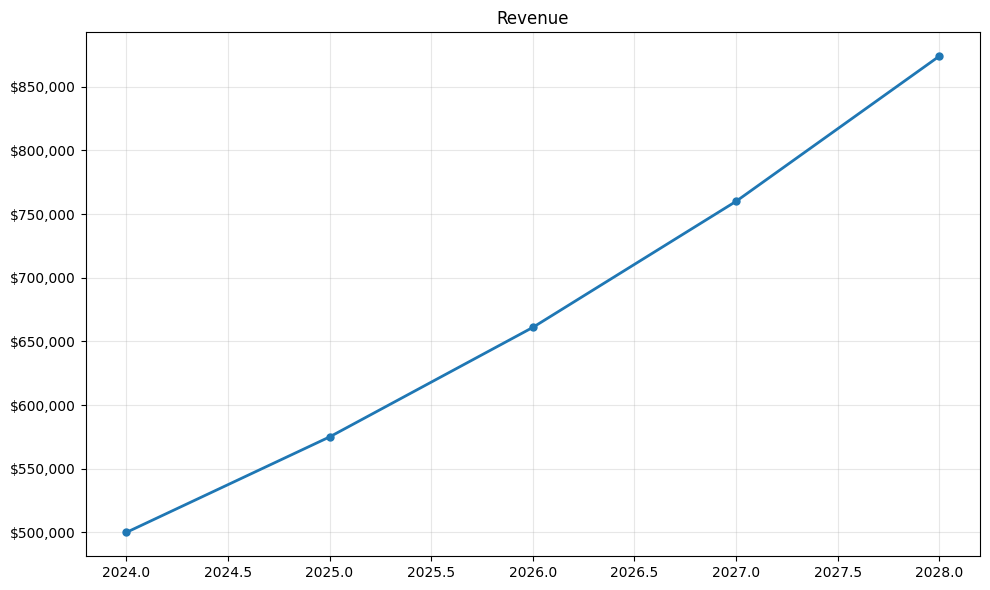

In [3]:
model.charts.line_item("revenue").show()

## Single line item — bar chart


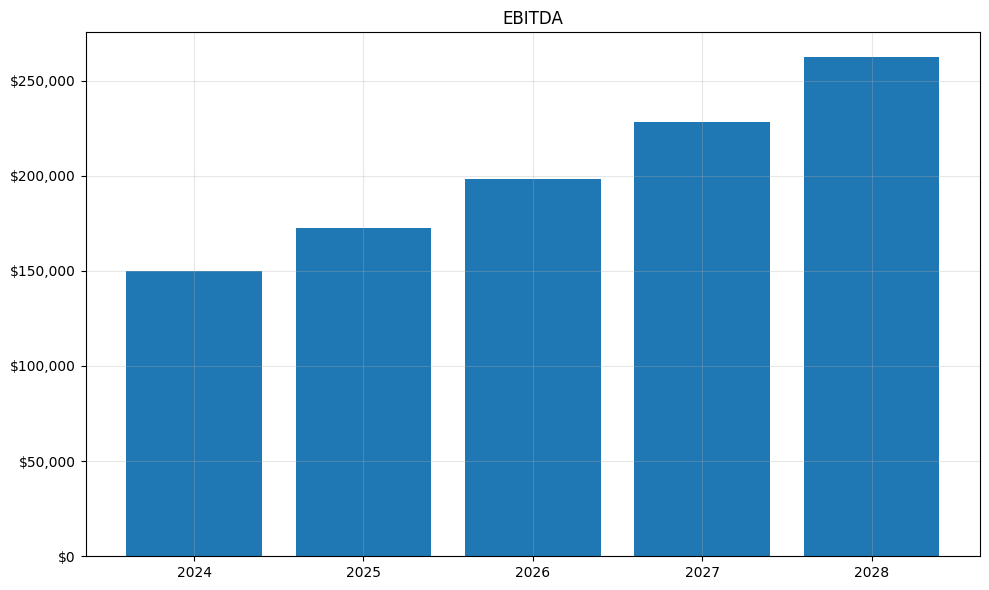

In [4]:
model.charts.line_item("ebitda", chart_type="bar").show()

## Convenience shortcut: `model[name].chart()`

When you already have a `LineItemResult`, `.chart()` delegates straight to `model.charts.line_item()`.


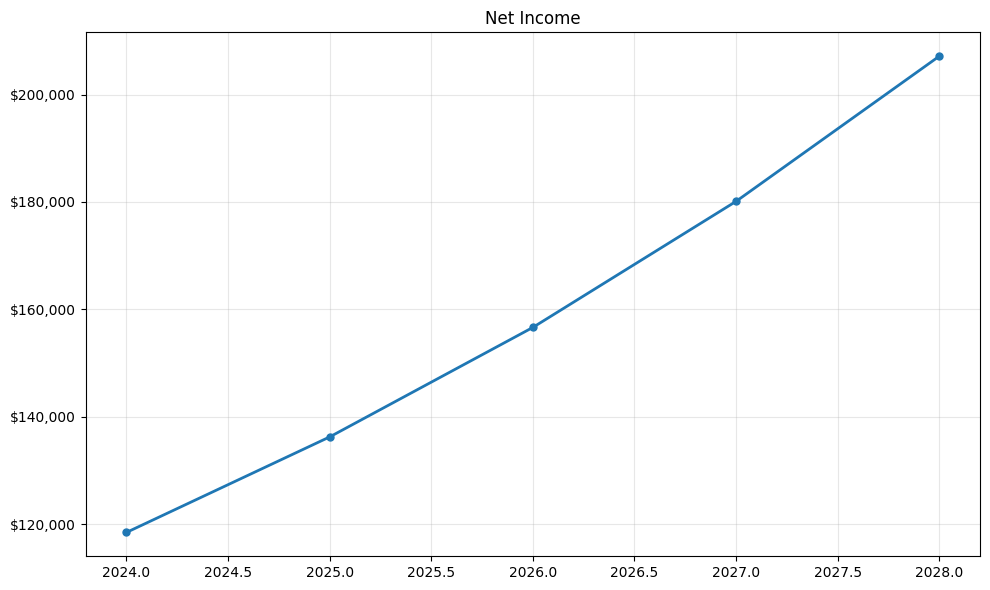

In [5]:
model["net_income"].chart().show()

## A percentage line item — y-axis formatted as %

Because `gross_margin` has `value_format=Format.PERCENT_ONE_DECIMAL`, the renderer
formats the y-axis ticks as percentages automatically.


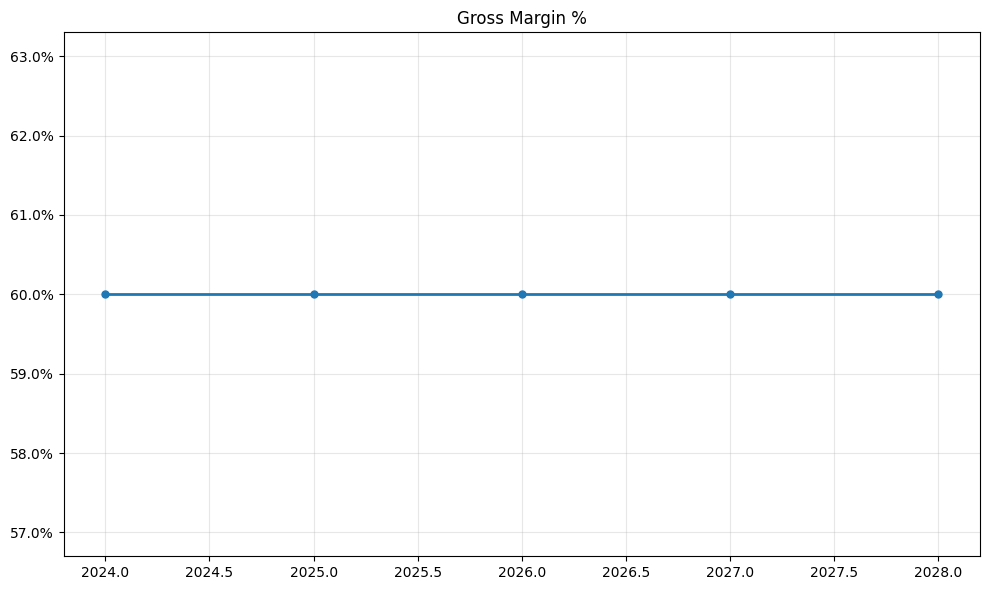

In [6]:
model["gross_margin"].chart(title="Gross Margin %").show()

## Multiple line items — line chart

`model.charts.line_items(names)` adds one series per item.


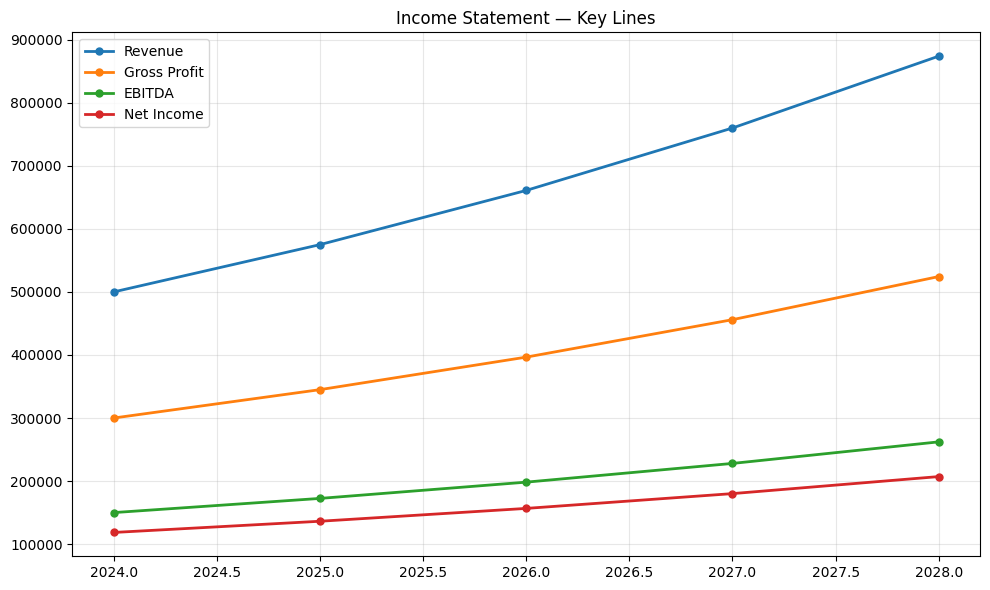

In [7]:
model.charts.line_items(
    ["revenue", "gross_profit", "ebitda", "net_income"],
    title="Income Statement — Key Lines",
).show()

## Multiple line items — grouped bar chart


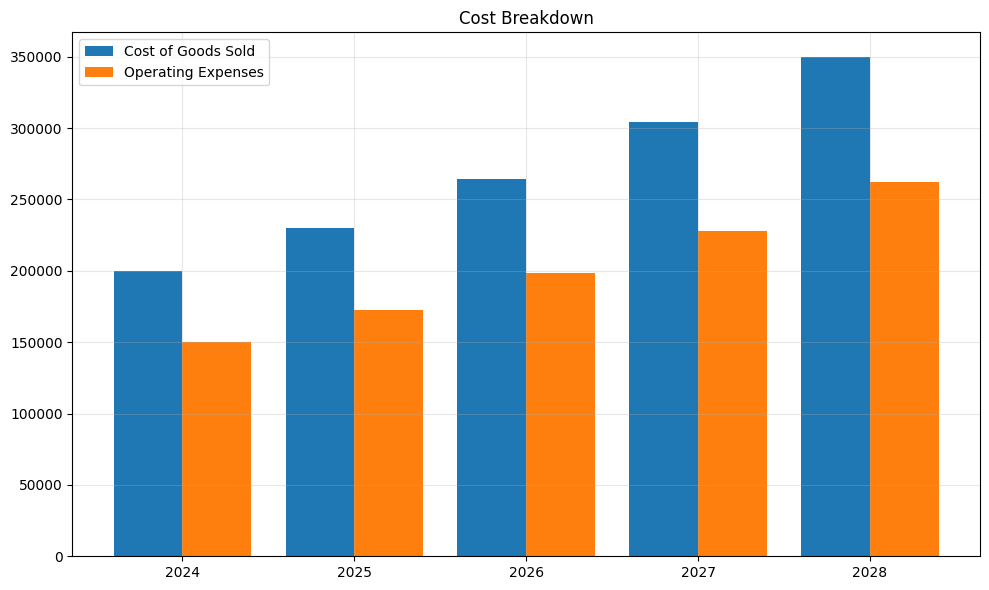

In [8]:
model.charts.line_items(
    ["cogs", "operating_expenses"],
    chart_type="bar",
    title="Cost Breakdown",
).show()

## Multiple line items — stacked bar chart


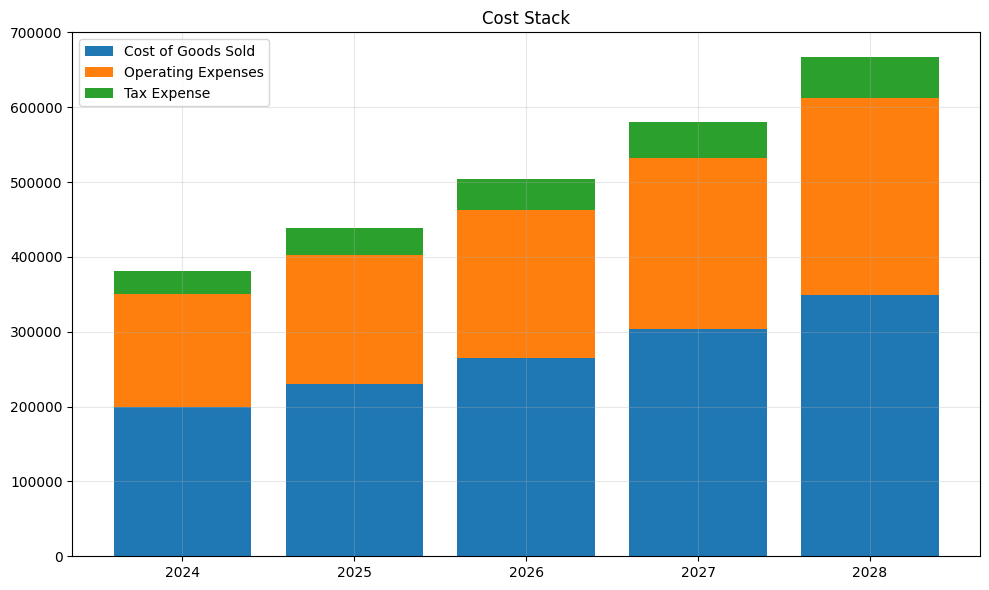

In [9]:
model.charts.line_items(
    ["cogs", "operating_expenses", "tax_expense"],
    chart_type="stacked_bar",
    title="Cost Stack",
).show()

## Accessing the Figure for further customisation

`.figure()` returns a `matplotlib.figure.Figure` so you can add annotations,
change styling, or save to disk.


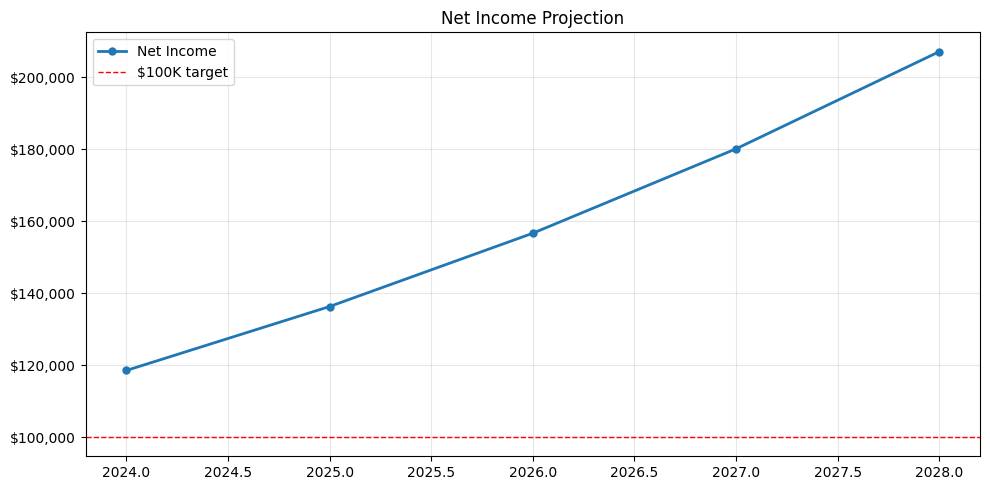

In [10]:
import matplotlib.pyplot as plt

fig = model.charts.line_item("net_income", title="Net Income Projection").figure(figsize=(10, 5))

# Access the axes and customise freely
ax = fig.axes[0]
ax.axhline(y=100_000, color="red", linestyle="--", linewidth=1, label="$100K target")
ax.legend()

plt.show()

## The data layer: `ChartSpec.to_dict()`

`ChartSpec` is a backend-agnostic data object. `.to_dict()` serialises it to plain
Python — ready for JSON output, a future `ChartsJSRenderer`, or any other consumer.


In [11]:
import json

spec = model.charts.line_item("revenue")
print(json.dumps(spec.to_dict(), indent=2))

{
  "chart_type": "line",
  "title": "Revenue",
  "x_label": null,
  "y_label": null,
  "series": [
    {
      "label": "Revenue",
      "x_values": [
        2024,
        2025,
        2026,
        2027,
        2028
      ],
      "y_values": [
        500000,
        575000,
        661000,
        760000,
        874000
      ],
      "color": null
    }
  ],
  "value_format": {
    "decimals": 0,
    "thousands": true,
    "prefix": "$",
    "suffix": "",
    "multiplier": 1.0,
    "scale": null
  }
}
